In [1]:
import sys
sys.path.append("../src")
import torch
import torch.nn as nn
import random
from data import generate_examples
from model import DyckTransformer

In [2]:
VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
edit_stoi = {"OK": 0, "DELETE": 1, "INSERT())": 2, "INSERT(])": 3, "REPLACE())": 4, "REPLACE(])": 5}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
model = DyckTransformer(
    vocab_size=len(VOCAB),
    pad_idx=stoi["[PAD]"],
    num_edit_labels=6,
    d_model=128,
    n_heads=4,
    n_layers=2,
    max_len=80,
    dropout=0.1
)
model.load_state_dict(torch.load("../results/models/det_dyck_transformer.pt", map_location=device))
model.to(device)

batch_size = 64
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [4]:
cor_train_data = generate_examples(50000, task="correction")
cor_dev_data = generate_examples(5000, task="correction")

In [5]:
cor_loss_curve = []
cor_train_acc_curve = []
cor_dev_acc_curve = []

cor_loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    total_loss = 0
    total_acc = 0
    n_train_batches = 0

    for i in range(0, len(cor_train_data), batch_size):
        batch = cor_train_data[i:i+batch_size]
        xs, ys = zip(*batch)
        xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
        ys = torch.tensor([[edit_stoi[l] for l in labels] for labels in ys]).to(device)

        _, token_logits = model(xs)
        loss = cor_loss_fn(token_logits.permute(0, 2, 1), ys)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = torch.argmax(token_logits, dim=2)
        acc = (preds == ys).float().mean().item()
        total_loss += loss.item()
        total_acc += acc
        n_train_batches += 1

    avg_loss = total_loss / n_train_batches
    avg_acc = total_acc / n_train_batches
    cor_loss_curve.append(avg_loss)
    cor_train_acc_curve.append(avg_acc)

    # dev evaluation
    model.eval()
    dev_acc = 0
    n_dev_batches = 0

    with torch.no_grad():
        for i in range(0, len(cor_dev_data), batch_size):
            batch = cor_dev_data[i:i+batch_size]
            xs, ys = zip(*batch)
            xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
            ys = torch.tensor([[edit_stoi[l] for l in labels] for labels in ys]).to(device)
            _, token_logits = model(xs)
            preds = torch.argmax(token_logits, dim=2)
            dev_acc += (preds == ys).float().mean().item()
            n_dev_batches += 1

    dev_acc /= n_dev_batches
    cor_dev_acc_curve.append(dev_acc)
    print(f"epoch {epoch} | loss {avg_loss:.4f} | train acc {avg_acc:.4f} | dev acc {dev_acc:.4f}")

c:\Users\sarav\projects\dyck_transformer\.pixi\envs\default\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\bld\libtorch_1772176602146\work\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


epoch 0 | loss 0.0448 | train acc 0.9891 | dev acc 0.9936
epoch 1 | loss 0.0217 | train acc 0.9938 | dev acc 0.9937
epoch 2 | loss 0.0211 | train acc 0.9939 | dev acc 0.9938
epoch 3 | loss 0.0205 | train acc 0.9939 | dev acc 0.9939
epoch 4 | loss 0.0197 | train acc 0.9940 | dev acc 0.9941
epoch 5 | loss 0.0184 | train acc 0.9943 | dev acc 0.9946
epoch 6 | loss 0.0172 | train acc 0.9947 | dev acc 0.9949
epoch 7 | loss 0.0164 | train acc 0.9949 | dev acc 0.9951
epoch 8 | loss 0.0159 | train acc 0.9950 | dev acc 0.9951
epoch 9 | loss 0.0156 | train acc 0.9951 | dev acc 0.9952


In [6]:
# save updated model
torch.save(model.state_dict(), "../results/models/dyck_transformer.pt")

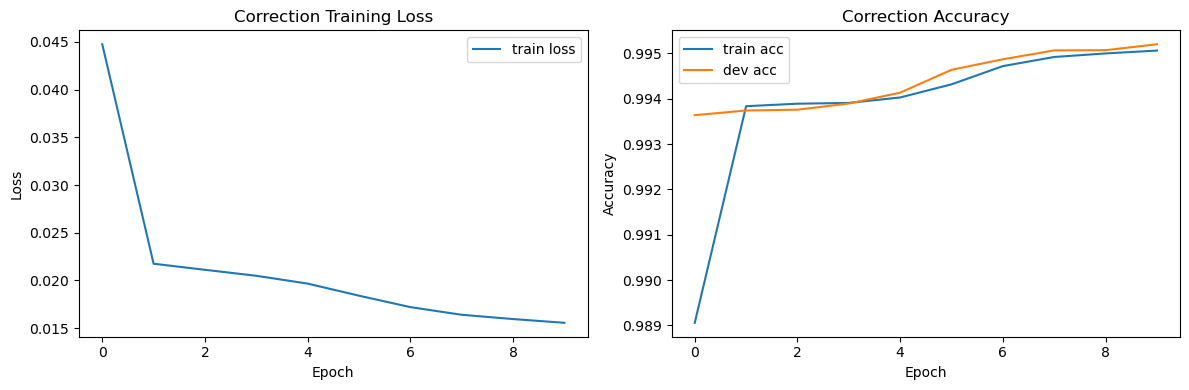

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(cor_loss_curve, label="train loss")
ax1.set_title("Correction Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(cor_train_acc_curve, label="train acc")
ax2.plot(cor_dev_acc_curve, label="dev acc")
ax2.set_title("Correction Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("../results/figures/cor_training_curves.pdf")
plt.show()